# R21 preliminary experiment: counterfactual scoring under renal biomarker distortion

A restart-clean, fully scripted synthetic experiment for the professor meeting. The numerical result is generated from stored ground truth; no ARCADIA patient data are used.

## tl;dr

- With no renal distortion, true-mechanism accuracy was
  **81.0%** for kidney-blind posterior matching and
  **81.1%** for kidney-aware counterfactual scoring.
- Under the strong 2.25-SD renal effect, accuracy was
  **73.6%** versus
  **81.2%**, respectively.
- In renal-impaired patients whose true mechanism was competing, strong
  distortion produced false atrial classification of
  **72.4%** versus
  **13.4%**.
- In the homogeneous K=1 null, the corrected selection pipeline chose a
  spurious K=2 model in **0 of
  500** repeats
  (Wilson 95% CI 0.0% to
  0.8%).

The gain over kidney-blind matching is evidence for representing the renal
biomarker path. It is **not** evidence that counterfactual syntax outperforms a
correctly specified posterior: in this symmetric toy SCM, the counterfactual
ranking and same-SCM posterior ranking are intentionally equivalent.

## Context & Methods

### Key assumptions

- Each patient has one true categorical latent mechanism: atrial or competing. Posterior probabilities encode uncertainty, not biological mixture membership.
- Renal dysfunction influences mechanism prevalence and directly raises the NT-proBNP-like biomarker.
- The primary baseline deliberately omits the direct renal path. The counterfactual scorer and same-SCM posterior include it.
- Parameters are known (oracle simulation). This isolates scoring behavior before parameter learning, missingness, and graph misspecification are introduced.

The counterfactual calculation enumerates both latent branches, abducts a branch-specific exogenous residual, reuses that residual under intervention, and posterior-averages normalized disablement and sufficiency. See `R21_PRELIMINARY_METHODOLOGY.md` for the full estimand and interpretation boundary.

In [1]:
from dataclasses import asdict
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

from r21_preliminary_experiment import (
    ExperimentConfig,
    METHOD_COUNTERFACTUAL,
    METHOD_POSTERIOR_BLIND,
    METHOD_POSTERIOR_FULL,
    kidney_aware_posterior,
    posterior_integrated_counterfactual_scores,
    run_full_experiment,
    simulate_two_mechanism_study,
)

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / 'outputs'
CONFIG = ExperimentConfig()
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)
asdict(CONFIG)

{'seed': 20260728,
 'patients_per_repeat': 1000,
 'repeats_per_level': 500,
 'renal_prevalence': 0.3,
 'atrial_log_odds_when_renal_normal': 0.0,
 'renal_to_atrial_log_odds': -0.4,
 'confounding_strengths_sd': (0.0, 0.75, 1.5, 2.25),
 'confounding_labels': ('None\n(0 SD)',
  'Weak\n(0.75 SD)',
  'Moderate\n(1.50 SD)',
  'Strong\n(2.25 SD)'),
 'mechanism_effects': ((1.2, 0.8, 0.0), (0.0, 0.0, 1.0)),
 'biomarker_noise_sd': (1.0, 1.0, 1.0),
 'counterfactual_disablement_weight': 0.5,
 'counterfactual_sufficiency_weight': 0.5,
 'null_repeats': 500,
 'null_patients_per_repeat': 1000,
 'null_renal_effect_sd': 2.25,
 'null_gmm_starts': 5,
 'null_gmm_max_iter': 400,
 'null_min_component_weight': 0.1,
 'gmm_variance_floor': 0.05}

## Data

The cell below runs 500 paired simulated studies at each of four renal-effect levels and 500 independent K=1 null studies. It overwrites only files inside `outputs/`.

In [2]:
artifacts = run_full_experiment(CONFIG, OUTPUT_DIR)
print(f"Saved outputs to: {OUTPUT_DIR.resolve()}")

Saved outputs to: /Users/neeamhayder/Documents/ESUS Endotyping with Causal Models/outputs


### Reasonableness and invariance checks

These checks catch the original notebook's failure modes: missing repeats, probability errors, discarded score components, and unsupported claims that the causal query beats the posterior that generated it.

In [3]:
summary = artifacts['summary']
raw = artifacts['raw_metrics']

assert raw.groupby(['strength_index', 'method', 'metric']).size().eq(CONFIG.repeats_per_level).all()
assert raw['value'].between(0, 1).all()
assert summary[['ci_low', 'mean', 'ci_high']].apply(
    lambda row: row['ci_low'] <= row['mean'] <= row['ci_high'], axis=1
).all()

# In the symmetric K=2 toy SCM, the normalized counterfactual rank
# is deliberately equivalent to the same-SCM posterior rank.
check_rng = np.random.default_rng(CONFIG.seed + 99)
check_data = simulate_two_mechanism_study(CONFIG, 1.5, check_rng)
check_cf = posterior_integrated_counterfactual_scores(
    check_data['biomarkers'], check_data['renal'], 1.5, CONFIG
)
check_posterior = kidney_aware_posterior(
    check_data['biomarkers'], check_data['renal'], 1.5, CONFIG
)
np.testing.assert_allclose(check_cf['combined'], check_posterior, atol=1e-12)
print('All structural, range, CI, and same-SCM invariance checks passed.')

All structural, range, CI, and same-SCM invariance checks passed.


## Results

### Figure P1

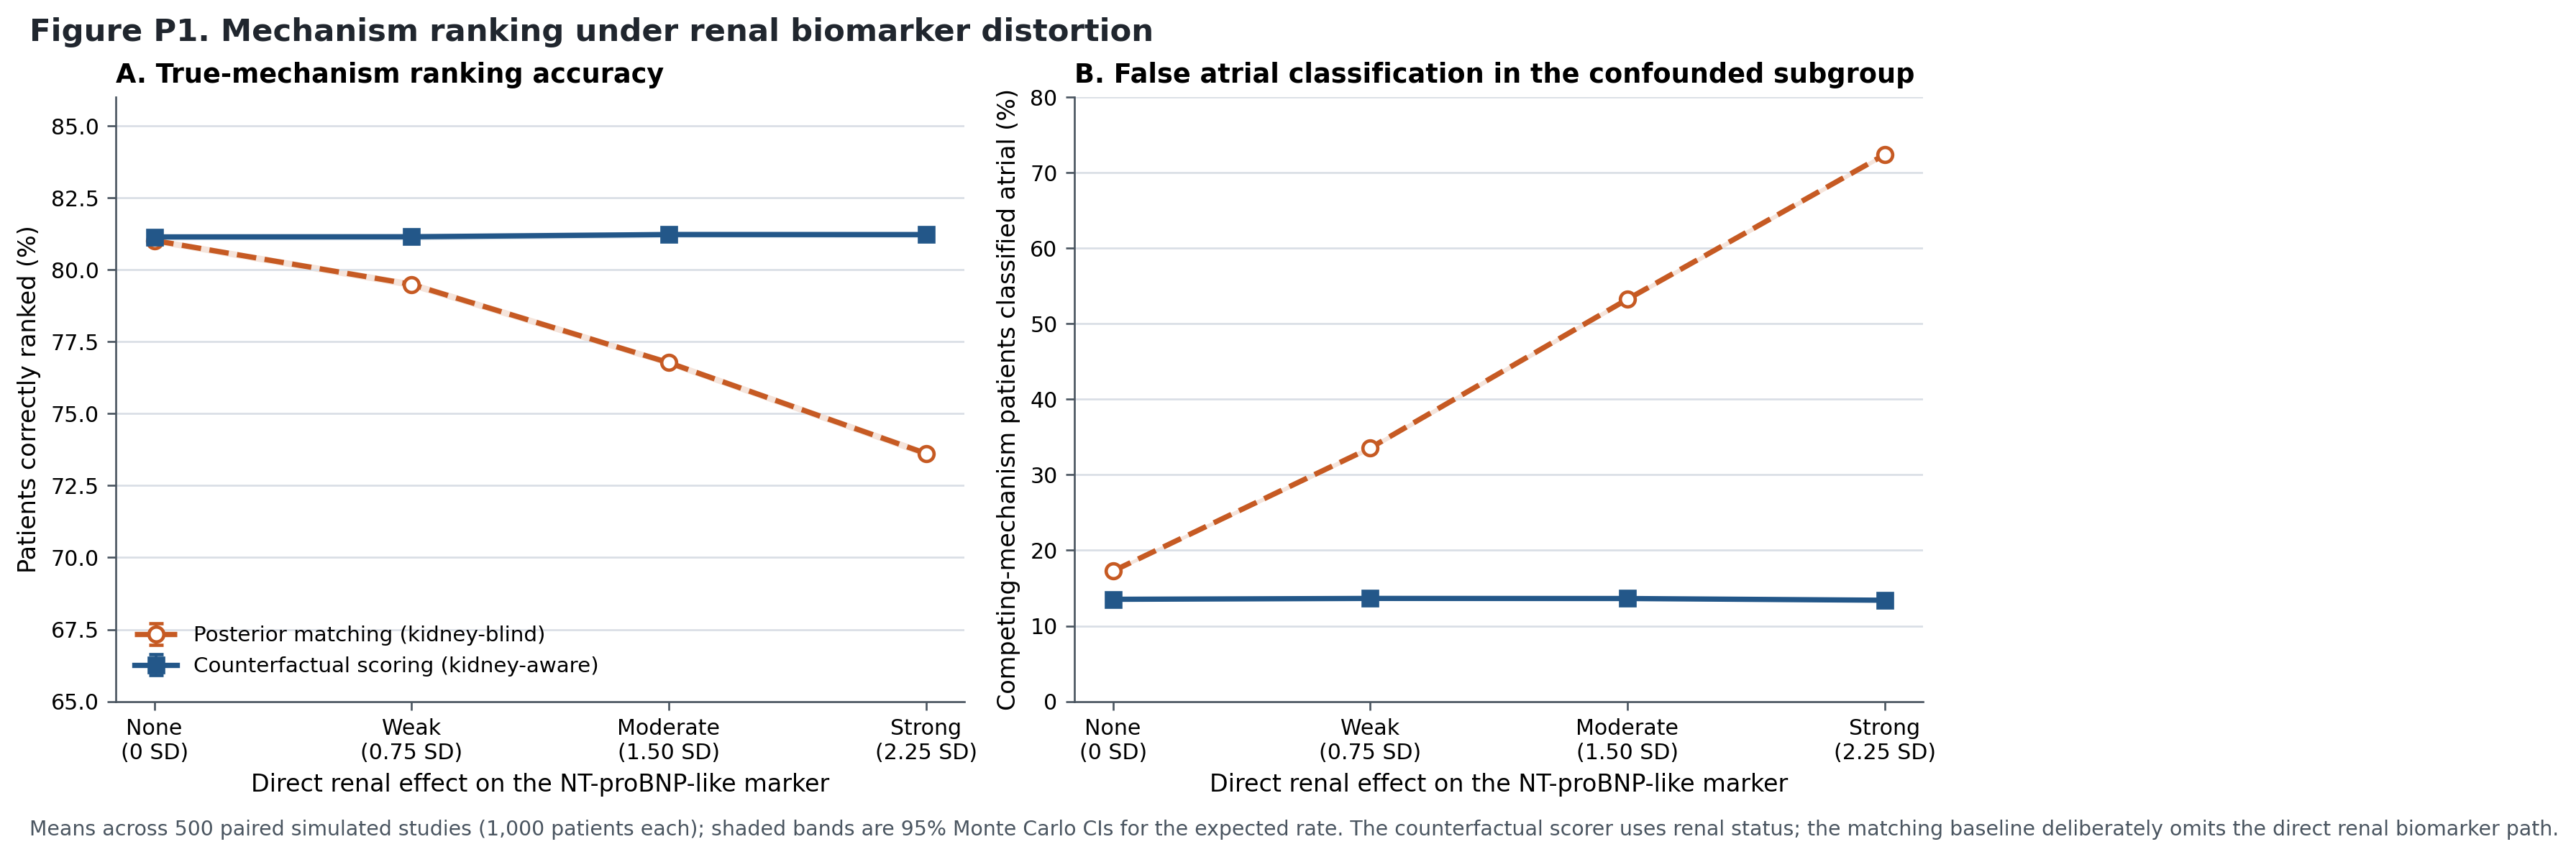

In [4]:
display(Image(filename=str(artifacts['figure_png']), width=1150))

### Exact main-effect estimates

The shaded figure intervals are 95% Monte Carlo confidence intervals for the expected rate. `repeat_q025` and `repeat_q975` in the saved CSV describe the wider distribution of study-level estimates.

In [5]:
main_table = summary[
    summary['method'].isin([METHOD_POSTERIOR_BLIND, METHOD_COUNTERFACTUAL])
][[
    'renal_effect_sd', 'method', 'metric', 'n_repeats',
    'mean', 'ci_low', 'ci_high', 'repeat_q025', 'repeat_q975',
    'mean_denominator'
]].copy()
for column in ['mean', 'ci_low', 'ci_high', 'repeat_q025', 'repeat_q975']:
    main_table[column] = (100 * main_table[column]).round(2)
display(main_table)

,renal_effect_sd,method,metric,n_repeats,mean,ci_low,ci_high,repeat_q025,repeat_q975,mean_denominator
0,0.00,Counterfactual scoring (kidney-aware),false_atrial_confounded_competing,500,13.52,13.31,13.73,8.91,18.39,178.970
1,0.00,Counterfactual scoring (kidney-aware),true_mechanism_accuracy,500,81.14,81.03,81.25,78.70,83.50,1000.000
4,0.00,Posterior matching (kidney-blind),false_atrial_confounded_competing,500,17.25,17.02,17.49,12.05,22.54,178.970
5,0.00,Posterior matching (kidney-blind),true_mechanism_accuracy,500,81.01,80.90,81.12,78.55,83.35,1000.000
6,0.75,Counterfactual scoring (kidney-aware),false_atrial_confounded_competing,500,13.64,13.41,13.86,8.90,18.92,179.510
7,0.75,Counterfactual scoring (kidney-aware),true_mechanism_accuracy,500,81.14,81.03,81.26,78.50,83.55,1000.000
10,0.75,Posterior matching (kidney-blind),false_atrial_confounded_competing,500,33.55,33.22,33.88,26.23,40.82,179.510
11,0.75,Posterior matching (kidney-blind),true_mechanism_accuracy,500,79.49,79.37,79.61,76.65,82.05,1000.000
12,1.50,Counterfactual scoring (kidney-aware),false_atrial_confounded_competing,500,13.62,13.41,13.84,9.06,18.39,179.176
13,1.50,Counterfactual scoring (kidney-aware),true_mechanism_accuracy,500,81.22,81.11,81.33,78.75,83.60,1000.000


### Fairness diagnostic

Top-1 accuracy from the same renal-aware posterior must be checked against the counterfactual ranking. If the counterfactual method appeared systematically superior here, the implementation or comparison would require investigation.

In [6]:
diagnostic = summary[
    (summary['metric'] == 'true_mechanism_accuracy')
    & summary['method'].isin([METHOD_COUNTERFACTUAL, METHOD_POSTERIOR_FULL])
][['renal_effect_sd', 'method', 'mean', 'ci_low', 'ci_high']].copy()
for column in ['mean', 'ci_low', 'ci_high']:
    diagnostic[column] = (100 * diagnostic[column]).round(3)
display(diagnostic)

,renal_effect_sd,method,mean,ci_low,ci_high
1,0.00,Counterfactual scoring (kidney-aware),81.139,81.031,81.246
3,0.00,Posterior (same kidney-aware SCM),81.139,81.031,81.246
7,0.75,Counterfactual scoring (kidney-aware),81.144,81.030,81.258
9,0.75,Posterior (same kidney-aware SCM),81.144,81.030,81.258
13,1.50,Counterfactual scoring (kidney-aware),81.222,81.114,81.330
15,1.50,Posterior (same kidney-aware SCM),81.222,81.114,81.330
19,2.25,Counterfactual scoring (kidney-aware),81.220,81.111,81.329
21,2.25,Posterior (same kidney-aware SCM),81.220,81.111,81.329


### K = 1 null

In [7]:
null_table = artifacts['null_summary'].copy()
for column in ['false_k2_rate', 'wilson_ci_low', 'wilson_ci_high', 'k2_convergence_rate']:
    null_table[column] = (100 * null_table[column]).round(2)
display(null_table)

,truth_k,comparison,repeats,false_k2_selections,false_k2_rate,wilson_ci_low,wilson_ci_high,k2_convergence_rate,median_bic_k2_minus_k1
0,1,BIC-selected K=1 versus K=2 after renal adjust...,500,0,0.0,0.0,0.76,100.0,40.929586


## Takeaways

1. The clean preliminary result is a stress test of **renal-aware causal specification**, not a proof that counterfactual querying beats an exact posterior.
2. Figure P1 directly reports both requested outcomes: overall true-mechanism ranking and false atrial classification in the confounded competing-mechanism subgroup.
3. The K=1 result is protected by explicit model selection. A fixed-K run would be circular.
4. The next experiment should introduce parameter learning and prespecified graph misspecification. Missingness and the full ARCADIA biology should remain out of this first figure.